# 🤖 Notebook 04 — Modelo Baseline

Entrenamos el modelo más simple posible que funcione bien:
**Logistic Regression** sobre TF-IDF.
Este es nuestro punto de referencia — cualquier modelo más complejo
debe superar estas métricas para justificar su complejidad.

**Usamos Logistic Regression como baseline:**
- Funciona excepcionalmente bien con matrices TF-IDF sparse
- Coeficientes interpretables: podemos ver exactamente qué palabras usa
- Rápido de entrenar y difícil de sobreajustar con regularización
- En NLP, LR bate a modelos más complejos sorprendentemente seguido

### Alerta del notebook anterior
El análisis de features detectó nombres propios (`stefan`, `peggy`, `hubbard`)
con alto peso en la clase no-tóxica. Analizaremos si el modelo los aprende
y tomaremos acción si es necesario.

### Output
- Métricas baseline: F1, Precision, Recall, ROC-AUC
- Análisis de coeficientes (qué aprendió el modelo)
- Análisis de errores (qué falla y por qué)
- Experimento en MLflow: `04_baseline`
- Modelo guardado: `models/lr_baseline.joblib`

## 0. Imports y configuración

In [1]:
print("kernel")

kernel


In [2]:
import sys
import yaml
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

/Users/miraekang/proyectos/ai-nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /Users/miraekang/proyectos/ai-nlp


In [3]:
CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'
CONFIG_MOD  = PROJECT_ROOT / 'configs' / 'models.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)
with open(CONFIG_MOD)  as f: mod_cfg  = yaml.safe_load(f)

tfidf_cfg = feat_cfg['vectorization']['tfidf']
lr_cfg    = mod_cfg['models']['logistic_regression']
TARGET    = pipe_cfg['data']['target_binary']
SUBLABELS = pipe_cfg['data']['target_multilabel']
RAND      = pipe_cfg['pipeline']['random_state']
TEST_SIZE = pipe_cfg['pipeline']['test_size']
CV_FOLDS  = pipe_cfg['pipeline']['cv_folds']

print('LR config:', lr_cfg)
print(f'CV folds : {CV_FOLDS} | random_state: {RAND}')

LR config: {'C': 0.4, 'max_iter': 1000, 'class_weight': 'balanced', 'solver': 'lbfgs'}
CV folds : 5 | random_state: 42


## 1. Carga de datos y split

Mismo split que en vectorización — `random_state` fijo desde YAML
garantiza que train/test son idénticos en todos los notebooks.

In [4]:
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'

df = pd.read_csv(PROCESSED)
df['clean_text'] = df['clean_text'].fillna('').astype(str)

X = df['clean_text']
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND, stratify=y
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train positivos: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test positivos : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train: 797 | Test: 200
Train positivos: 367 (46.0%)
Test positivos : 92 (46.0%)


## 2. Pipeline sklearn

Encadenamos TF-IDF + Logistic Regression en un `sklearn.Pipeline`.

### ¿Por qué Pipeline y no pasos separados?
- En cross-validation, el Pipeline hace `fit` del TF-IDF **dentro** de cada fold
  usando solo los datos de ese fold de entrenamiento
- Si vectorizáramos fuera del Pipeline, el TF-IDF vería todos los folds → data leakage
- Además, el Pipeline es directamente serializable con `joblib` y deployable

### Parámetros de Logistic Regression
- `C=1.0` → regularización L2 por defecto (penaliza coeficientes grandes)
- `class_weight='balanced'` → compensa si hay desbalance entre clases
- `max_iter=1000` → suficiente para convergencia con datos sparse
- `solver='lbfgs'` → eficiente para problemas medianos con L2

In [5]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = tfidf_cfg['max_features'],
        ngram_range  = tuple(tfidf_cfg['ngram_range']),
        sublinear_tf = tfidf_cfg['sublinear_tf'],
        min_df       = tfidf_cfg['min_df'],
        analyzer     = 'word',
        strip_accents= 'unicode',
    )),
    ('clf', LogisticRegression(
        C            = lr_cfg['C'],
        max_iter     = lr_cfg['max_iter'],
        class_weight = lr_cfg['class_weight'],
        solver       = lr_cfg['solver'],
        random_state = RAND,
    ))
])

print('Pipeline creado:')
print(pipeline)

Pipeline creado:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, min_df=3,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(C=0.4, class_weight='balanced',
                                    max_iter=1000, random_state=42))])


## 3. Cross-Validation — evaluación real

Con 1000 muestras un solo split train/test no es fiable.
StratifiedKFold k=5 divide en 5 partes manteniendo la proporción de clases,
entrena en 4 y valida en 1, rotando las partes.

**Resultado:** 5 métricas → tomamos la media y la desviación estándar.
La std alta indica que el modelo es inestable con este dataset pequeño.

> La rúbrica exige diferencia train/test < 5 puntos porcentuales.
> Calculamos ambas para verificarlo.

In [6]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RAND)

# Métricas que queremos en cada fold
scoring = {
    'f1'       : 'f1_weighted',
    'precision': 'precision_weighted',
    'recall'   : 'recall_weighted',
    'roc_auc'  : 'roc_auc',
}

print(f'Ejecutando {CV_FOLDS}-fold cross-validation...')
cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,   # para detectar overfitting
    n_jobs=-1
)

print('Completado.\n')
print(f"{'Métrica':20} {'Train':>10} {'Val':>10} {'Gap(pp)':>15} {'Std Val':>10}")
print('-' * 70)

for metric in ['f1', 'precision', 'recall', 'roc_auc']:
    train_mean = cv_results[f'train_{metric}'].mean()
    val_mean   = cv_results[f'test_{metric}'].mean()
    val_std    = cv_results[f'test_{metric}'].std()
    gap_pp = abs(train_mean - val_mean) * 100

    flag       = '⚠️ Alto gap' if gap_pp > 5 else '✅ Estable'
    print(f'  {metric:18} {train_mean:>10.4f} {val_mean:>10.4f} {gap_pp:>11.2f} pp {val_std:>10.4f} {flag:>10}')


Ejecutando 5-fold cross-validation...
Completado.

Métrica                   Train        Val         Gap(pp)    Std Val
----------------------------------------------------------------------
  f1                     0.8908     0.7143       17.65 pp     0.0325 ⚠️ Alto gap
  precision              0.8909     0.7156       17.53 pp     0.0320 ⚠️ Alto gap
  recall                 0.8908     0.7151       17.57 pp     0.0324 ⚠️ Alto gap
  roc_auc                0.9589     0.7834       17.56 pp     0.0353 ⚠️ Alto gap


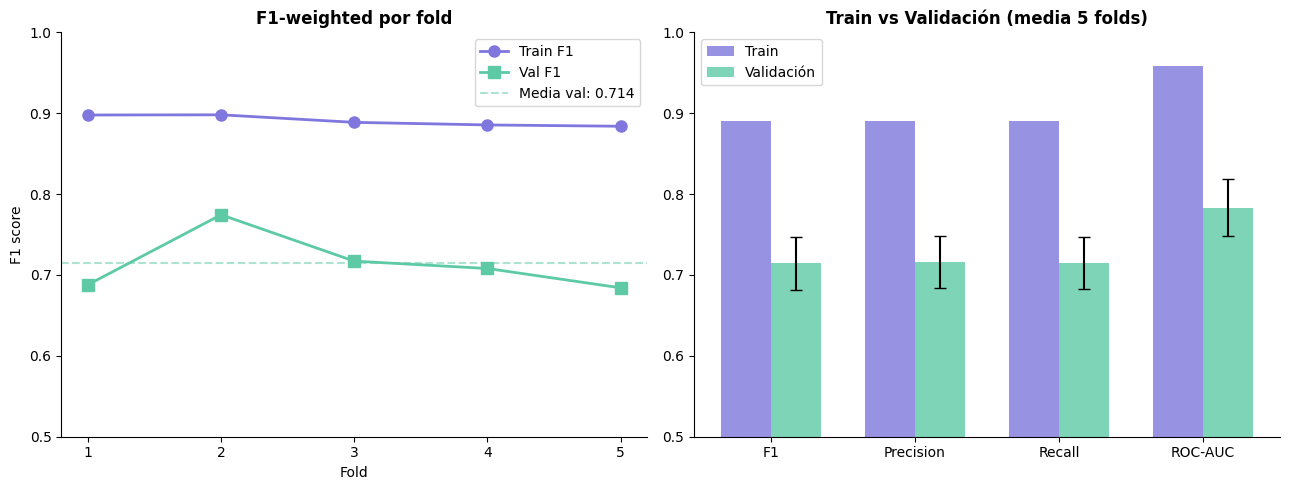

Guardado en reports/v2/09_cv_metrics.png


In [7]:
# Visualizacion de métricas por fold
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = ['f1', 'precision', 'recall', 'roc_auc']
colors_train = '#7F77DD'
colors_val   = '#5DCAA5'

# F1 por fold
folds = range(1, CV_FOLDS + 1)
axes[0].plot(folds, cv_results['train_f1'], 'o-', color=colors_train,
             label='Train F1', linewidth=2, markersize=8)
axes[0].plot(folds, cv_results['test_f1'], 's-', color=colors_val,
             label='Val F1', linewidth=2, markersize=8)
axes[0].axhline(cv_results['test_f1'].mean(), color=colors_val,
                linestyle='--', alpha=0.5, label=f'Media val: {cv_results["test_f1"].mean():.3f}')
axes[0].set_title('F1-weighted por fold', fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1 score')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()
axes[0].set_xticks(list(folds))

# Comparativa train vs val todas las métricas
x = np.arange(len(metrics))
width = 0.35
train_means = [cv_results[f'train_{m}'].mean() for m in metrics]
val_means   = [cv_results[f'test_{m}'].mean()  for m in metrics]
val_stds    = [cv_results[f'test_{m}'].std()   for m in metrics]

axes[1].bar(x - width/2, train_means, width, label='Train', color=colors_train, alpha=0.8)
axes[1].bar(x + width/2, val_means,   width, label='Validación', color=colors_val,
            alpha=0.8, yerr=val_stds, capsize=4)
axes[1].set_title('Train vs Validación (media 5 folds)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['F1', 'Precision', 'Recall', 'ROC-AUC'])
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '09_cv_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/v2/09_cv_metrics.png')

## 4. Evaluación final en test

Entrenamos el modelo en todo el train y evaluamos **una sola vez** en test.
Este es el número que reportamos como resultado final del baseline.

> ⚠️ El test set no se toca hasta este momento.
> Usarlo antes contamina la evaluación final.

In [8]:
# Entrenar en todo el train
pipeline.fit(X_train, y_train)

# Predecir en test
y_pred       = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred_train = pipeline.predict(X_train)

# Métricas train vs test (chequeo de overfitting para rúbrica)
f1_train = f1_score(y_train, y_pred_train, average='weighted')
f1_test  = f1_score(y_test,  y_pred,       average='weighted')


train_test_gap_pp = abs(f1_train - f1_test) * 100

cv_f1_mean = cv_results['test_f1'].mean()
cv_test_gap_pp = abs(cv_f1_mean - f1_test) * 100

print('=' * 55)
print('RESULTADOS FINALES — LOGISTIC REGRESSION BASELINE')
print('=' * 55)

print(f'F1-weighted Train : {f1_train:.4f}')
print(f'F1-weighted Test  : {f1_test:.4f}')
print(f'Train-Test Gap    : {train_test_gap_pp:.2f} pp')


print()

print(f'CV F1 Mean        : {cv_f1_mean:.4f}')
print(f'CV-Test Gap       : {cv_test_gap_pp:.2f} pp')

status = '✅ Estable' if cv_test_gap_pp < 5 else '⚠️ Alto gap'
print(f'Rubrica CV/Test   : {status}')

print()
print(classification_report(y_test, y_pred, target_names=['No toxico', 'Toxico']))

RESULTADOS FINALES — LOGISTIC REGRESSION BASELINE
F1-weighted Train : 0.8708
F1-weighted Test  : 0.7086
Train-Test Gap    : 16.22 pp

CV F1 Mean        : 0.7143
CV-Test Gap       : 0.57 pp
Rubrica CV/Test   : ✅ Estable

              precision    recall  f1-score   support

   No toxico       0.72      0.77      0.74       108
      Toxico       0.70      0.64      0.67        92

    accuracy                           0.71       200
   macro avg       0.71      0.70      0.71       200
weighted avg       0.71      0.71      0.71       200



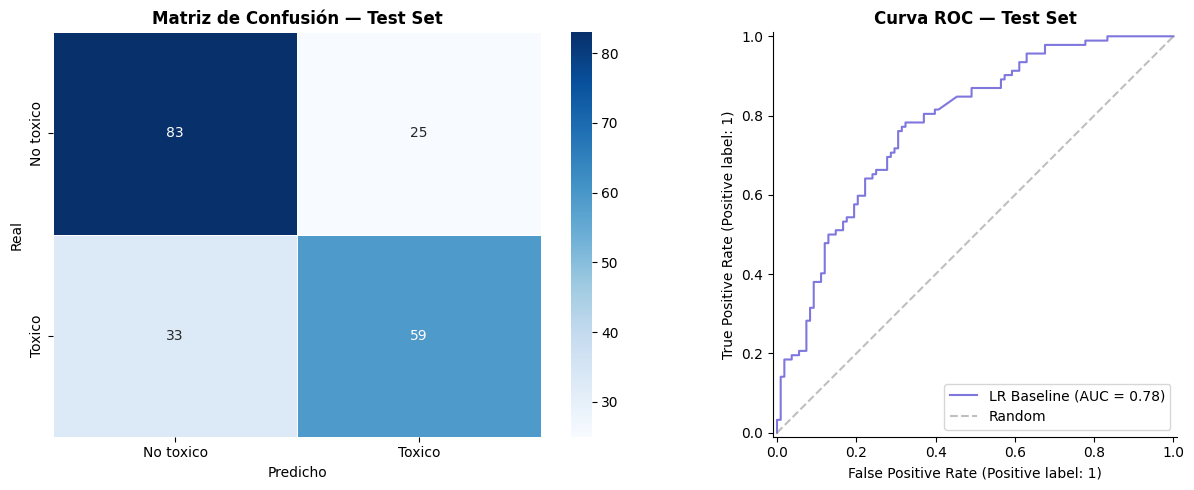

Guardado en reports/v2/10_baseline_confusion_roc.png


In [9]:
# Matriz de confusion + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No toxico','Toxico'],
            yticklabels=['No toxico','Toxico'],
            linewidths=0.5)
axes[0].set_title('Matriz de Confusión — Test Set', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1],
                                  color='#7F77DD', name='LR Baseline')
axes[1].plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random')
axes[1].set_title('Curva ROC — Test Set', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '10_baseline_confusion_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/v2/10_baseline_confusion_roc.png')

## 5. Análisis de coeficientes — ¿qué aprendió el modelo?

Los coeficientes de Logistic Regression indican el peso de cada feature.
Coeficiente positivo alto → predice TÓXICO.
Coeficiente negativo alto → predice NO TÓXICO.

**Buscamos específicamente** si el modelo aprendió nombres propios
(`stefan`, `peggy`, `hubbard`) en lugar de lenguaje tóxico real.
Si los vemos en top features → añadirlos a custom stopwords y re-ejecutar.

In [10]:
# Extraer coeficientes del clasificador dentro del pipeline
lr_model    = pipeline.named_steps['clf']
tfidf_model = pipeline.named_steps['tfidf']
feature_names = tfidf_model.get_feature_names_out()
coef = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'feature'    : feature_names,
    'coeficiente': coef
}).sort_values('coeficiente', ascending=False)

print('TOP 20 — Palabras que MAS predicen TOXICO (coef positivo):')
print(coef_df.head(20).to_string(index=False))
print()
print('TOP 20 — Palabras que MAS predicen NO TOXICO (coef negativo):')
print(coef_df.tail(20).sort_values('coeficiente').to_string(index=False))

TOP 20 — Palabras que MAS predicen TOXICO (coef positivo):
feature  coeficiente
   fuck     1.582224
    run     1.215538
  idiot     1.190952
   shit     1.155516
 stupid     0.932082
    ass     0.883411
  shoot     0.814162
   thug     0.737356
  bitch     0.731911
  white     0.682751
   dumb     0.657736
  black     0.593531
fucking     0.593391
   cunt     0.522571
    job     0.499430
    cnn     0.488097
  every     0.474585
   kill     0.472122
  masri     0.467155
  bunch     0.452629

TOP 20 — Palabras que MAS predicen NO TOXICO (coef negativo):
 feature  coeficiente
   peggy    -0.810510
   truth    -0.660594
   thank    -0.649197
  stefan    -0.631774
     say    -0.611535
   woman    -0.521453
     rap    -0.482543
    move    -0.481717
    tell    -0.476465
     put    -0.463828
    much    -0.460757
    good    -0.446983
  pretty    -0.442561
ferguson    -0.441739
 hubbard    -0.411202
   cigar    -0.410384
    side    -0.369870
   could    -0.352536
    fair    -0.3490

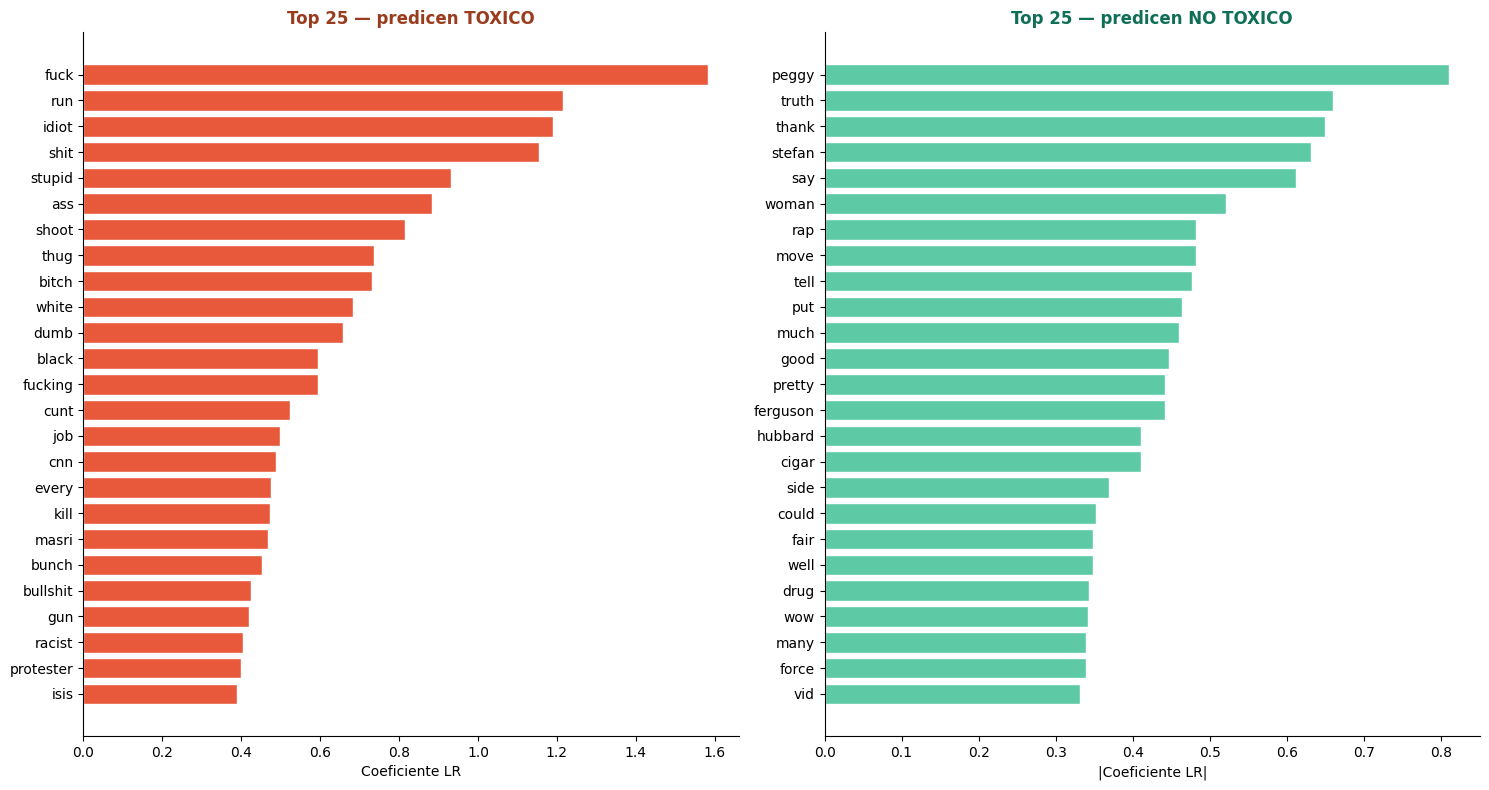

Guardado en reports/v2/11_lr_coeficientes.png

⚠️  Nombres propios / términos sospechosos en el modelo:
 feature  coeficiente
     cnn     0.488097
   cigar    -0.410384
 hubbard    -0.411202
ferguson    -0.441739
  stefan    -0.631774
   peggy    -0.810510

Considerar: añadir a custom_stopwords en preprocessing y re-ejecutar


In [11]:
# Visualizacion de coeficientes
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

top_pos = coef_df.head(25)
top_neg = coef_df.tail(25).sort_values('coeficiente')

axes[0].barh(top_pos['feature'], top_pos['coeficiente'],
             color='#E8593C', edgecolor='white')
axes[0].set_title('Top 25 — predicen TOXICO', fontweight='bold', color='#993C1D')
axes[0].set_xlabel('Coeficiente LR')
axes[0].invert_yaxis()

axes[1].barh(top_neg['feature'], top_neg['coeficiente'].abs(),
             color='#5DCAA5', edgecolor='white')
axes[1].set_title('Top 25 — predicen NO TOXICO', fontweight='bold', color='#0F6E56')
axes[1].set_xlabel('|Coeficiente LR|')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '11_lr_coeficientes.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/v2/11_lr_coeficientes.png')

# Alerta: ¿hay nombres propios en top features?
suspicious = ['stefan','peggy','hubbard','ferguson','cigar','cnn']
found = coef_df[coef_df['feature'].isin(suspicious)]
if len(found) > 0:
    print('\n⚠️  Nombres propios / términos sospechosos en el modelo:')
    print(found.to_string(index=False))
    print('\nConsiderar: añadir a custom_stopwords en preprocessing y re-ejecutar')
else:
    print('\n✅ No se detectaron nombres propios en top features')

## 6. Análisis de errores

Los errores del modelo son tan importantes como sus aciertos.
Entender qué falla nos guía para mejorar el preprocesamiento,
cambiar el vectorizador o ajustar hiperparámetros.

**Falso Positivo (FP):** comentario NO tóxico clasificado como TÓXICO → censura incorrecta.
**Falso Negativo (FN):** comentario TÓXICO clasificado como NO tóxico → hate speech no detectado.

Para la app de YouTube: los FN son más dañinos (dejan pasar hate speech).

In [12]:
# Reconstruir DataFrame de test para analisis
test_df = df.iloc[X_test.index].copy()
test_df['predicted'] = y_pred
test_df['proba_toxic'] = y_pred_proba
test_df['correct'] = test_df[TARGET] == test_df['predicted']

# Falsos positivos y negativos
fp = test_df[(test_df[TARGET] == False) & (test_df['predicted'] == True)]
fn = test_df[(test_df[TARGET] == True)  & (test_df['predicted'] == False)]

print(f'Total test   : {len(test_df)}')
print(f'Correctos    : {test_df["correct"].sum()} ({test_df["correct"].mean()*100:.1f}%)')
print(f'Falsos Pos   : {len(fp)} — no toxicos clasificados como toxicos')
print(f'Falsos Neg   : {len(fn)} — toxicos NO detectados')
print()

print('FALSOS POSITIVOS (el modelo censura incorrectamente):')
print('-' * 65)
for _, row in fp.nlargest(5, 'proba_toxic').iterrows():
    print(f'  Prob: {row["proba_toxic"]:.3f} | {row["Text"][:100]}')
    print(f'  Limpio: {row["clean_text"][:80]}')
    print()

print('FALSOS NEGATIVOS (hate speech que se escapa):')
print('-' * 65)
for _, row in fn.nsmallest(5, 'proba_toxic').iterrows():
    print(f'  Prob: {row["proba_toxic"]:.3f} | {row["Text"][:100]}')
    print(f'  Limpio: {row["clean_text"][:80]}')
    print()

Total test   : 200
Correctos    : 142 (71.0%)
Falsos Pos   : 25 — no toxicos clasificados como toxicos
Falsos Neg   : 33 — toxicos NO detectados

FALSOS POSITIVOS (el modelo censura incorrectamente):
-----------------------------------------------------------------
  Prob: 0.671 | Who the fuck has time to be on the freeway???
  Limpio: fuck time freeway

  Prob: 0.601 | If that cop shot a white guy, there would not be any riots. But since he shot a black guy, everyone 
  Limpio: cop shoot white guy would riot since shoot black guy everyone seem think black l

  Prob: 0.591 | 7:28 Lost my shit to that GUY. lmao
  Limpio: lose shit guy lmao

  Prob: 0.587 | police shot 1 black guy , & then the blacks riot ,!! when a black shoot a black , what happens ?? ,,
  Limpio: police shoot black guy black riot black shoot black happen

  Prob: 0.584 | people get shot everyday, how come this is the only one thats getting attention
  Limpio: people get shoot everyday come one get attention

FALSOS NE

## 7. Registro en MLflow

Guardamos todo en MLflow para poder comparar este baseline
contra los modelos ensemble del siguiente notebook.

In [13]:
MLFLOW_DIR = PROJECT_ROOT / 'mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('Youtube_project_experiment')

with mlflow.start_run(run_name='lr_baseline'):

    # Params
    mlflow.log_param('model',          'LogisticRegression')
    mlflow.log_param('C',              lr_cfg['C'])
    mlflow.log_param('max_iter',       lr_cfg['max_iter'])
    mlflow.log_param('class_weight',   lr_cfg['class_weight'])
    mlflow.log_param('solver',         lr_cfg['solver'])
    mlflow.log_param('tfidf_features', tfidf_cfg['max_features'])
    mlflow.log_param('ngram_range',    str(tuple(tfidf_cfg['ngram_range'])))
    mlflow.log_param('cv_folds',       CV_FOLDS)
    mlflow.log_param('vectorizer',     'tfidf')

    # Metrics CV
    mlflow.log_metric('cv_f1_mean',        cv_results['test_f1'].mean())
    mlflow.log_metric('cv_f1_std',         cv_results['test_f1'].std())
    mlflow.log_metric('cv_roc_auc_mean',   cv_results['test_roc_auc'].mean())
    mlflow.log_metric('cv_precision_mean', cv_results['test_precision'].mean())
    mlflow.log_metric('cv_recall_mean',    cv_results['test_recall'].mean())

    # Metrics test final
    mlflow.log_metric('test_f1',         f1_test)
    mlflow.log_metric('train_f1',        f1_train)
    # Gap clásico Train vs Test
    mlflow.log_metric('train_test_gap_pp', round(train_test_gap_pp, 2))

    # Consistencia CV vs Test
    mlflow.log_metric('cv_f1_mean', round(cv_f1_mean, 4))
    mlflow.log_metric('cv_test_gap_pp', round(cv_test_gap_pp, 2))
    mlflow.log_metric('test_roc_auc',    roc_auc_score(y_test, y_pred_proba))
    
    mlflow.log_metric('fp_count',        len(fp))
    mlflow.log_metric('fn_count',        len(fn))

    # Modelo
    mlflow.sklearn.log_model(pipeline, 'lr_baseline_pipeline')

    # Artefactos
    for png in ['09_cv_metrics','10_baseline_confusion_roc','11_lr_coeficientes']:
        mlflow.log_artifact(str(PROJECT_ROOT / 'reports' / 'v2' / f'{png}.png'))

    print(f'MLflow registrado')
    print(f'  Run ID     : {mlflow.active_run().info.run_id}')
    print(f'  Experimento: Youtube_project_experiment')
    print(f'  Run name   : lr_baseline')

2026/05/25 02:03:53 INFO mlflow.tracking.fluent: Experiment with name 'Youtube_project_experiment' does not exist. Creating a new experiment.
2026/05/25 02:03:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 02:03:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 02:03:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLflow registrado
  Run ID     : 690a2205048349e49d50abe0ebafb9fe
  Experimento: Youtube_project_experiment
  Run name   : lr_baseline


## 8. Guardar modelo

Guardamos el pipeline completo (TF-IDF + LR) en `models/`.
El pipeline incluye el vectorizador entrenado, por lo que basta
con cargar este archivo y llamar `.predict()` sobre texto limpio.

In [14]:
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / 'lr_baseline.joblib'
joblib.dump(pipeline, model_path)
print(f'Modelo guardado en: {model_path}')

# Verificacion: cargar y predecir
loaded = joblib.load(model_path)
test_comments = [
    'you are such a stupid thug get out',
    'I think the police should be more transparent',
    'black people are criminal thugs',
]
preds = loaded.predict(test_comments)
probas = loaded.predict_proba(test_comments)[:, 1]
print('\nVerificacion modelo cargado:')
for comment, pred, prob in zip(test_comments, preds, probas):
    label = 'TOXICO' if pred else 'NO TOXICO'
    print(f'  [{label} {prob:.2f}] {comment[:60]}')

Modelo guardado en: /Users/miraekang/proyectos/ai-nlp/models/lr_baseline.joblib

Verificacion modelo cargado:
  [TOXICO 0.74] you are such a stupid thug get out
  [NO TOXICO 0.43] I think the police should be more transparent
  [TOXICO 0.59] black people are criminal thugs


## 9. Conclusiones y decisiones

In [15]:
f1_cv = cv_results['test_f1'].mean()
roc_cv = cv_results['test_roc_auc'].mean()

train_test_gap_pp = abs(f1_train - f1_test) * 100
cv_test_gap_pp = abs(f1_cv - f1_test) * 100

cv_status = '✅ Estable' if cv_test_gap_pp < 5 else '⚠️ Alto gap'

print(f"""
CONCLUSIONES — BASELINE
=======================================================
Modelo : Logistic Regression + TF-IDF
Dataset: 800 train / 200 test / {CV_FOLDS}-fold CV

Metricas CV (media {CV_FOLDS} folds):
  F1-weighted  : {f1_cv:.4f}
  ROC-AUC      : {roc_cv:.4f}

Metricas test final:
  F1-weighted  : {f1_test:.4f}
  Train F1     : {f1_train:.4f}

Gaps:
  Train-Test Gap : {train_test_gap_pp:.2f} pp
  CV-Test Gap    : {cv_test_gap_pp:.2f} pp
  Rubrica CV/Test: {cv_status}

Errores:
  False Positives : {len(fp)}
  False Negatives : {len(fn)}

Coeficientes sospechosos detectados:
  Revisar si stefan/peggy/hubbard aparecen en top coef
  Si aparecen -> agregar a custom_stopwords
  y re-ejecutar preprocessing

""")


CONCLUSIONES — BASELINE
Modelo : Logistic Regression + TF-IDF
Dataset: 800 train / 200 test / 5-fold CV

Metricas CV (media 5 folds):
  F1-weighted  : 0.7143
  ROC-AUC      : 0.7834

Metricas test final:
  F1-weighted  : 0.7086
  Train F1     : 0.8708

Gaps:
  Train-Test Gap : 16.22 pp
  CV-Test Gap    : 0.57 pp
  Rubrica CV/Test: ✅ Estable

Errores:
  False Positives : 25
  False Negatives : 33

Coeficientes sospechosos detectados:
  Revisar si stefan/peggy/hubbard aparecen en top coef
  Si aparecen -> agregar a custom_stopwords
  y re-ejecutar preprocessing


